# Final Project: Quantitative Trading and Price Impact
**MSc in Mathematics and Finance — 2025-2026**

This notebook implements the full project pipeline:
1. Data Preparation
2. Volume Curves & VWAP Schedules
3. Volatility, ADV & Impact States
4. Impact Model Fitting (OW linear + square-root)
5. Synthetic Alphas
6. Backtest Engine
7. Optimal Trading Strategies
8. Performance Metrics
9. Sensitivity Analysis

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.signal import lfilter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

np.random.seed(42)
DATA_DIR = Path('data')

## 1. Data Preparation

In [19]:
files = sorted(DATA_DIR.glob('bin*.csv'))
print(f"Found {len(files)} monthly data files\n")

dfs = []
for f in files:
    df = pd.read_csv(f, parse_dates=['date'])
    dfs.append(df)
    print(f"  {f.name}: {len(df):>10,} rows  |  {df['date'].min().date()} → {df['date'].max().date()}")

data = pd.concat(dfs, ignore_index=True)
print(f"\nTotal: {len(data):,} rows, {data['stock'].nunique()} stocks, "
      f"{data['date'].nunique()} trading days")

Found 12 monthly data files

  bin201901.csv:  2,168,002 rows  |  2019-01-02 → 2019-01-31
  bin201902.csv:  2,018,914 rows  |  2019-02-01 → 2019-02-28
  bin201903.csv:  2,258,058 rows  |  2019-03-01 → 2019-03-29
  bin201904.csv:  2,185,122 rows  |  2019-04-01 → 2019-04-30
  bin201905.csv:  2,364,583 rows  |  2019-05-01 → 2019-05-31
  bin201906.csv:  2,103,978 rows  |  2019-06-03 → 2019-06-28
  bin201907.csv:  2,247,986 rows  |  2019-07-01 → 2019-07-31
  bin201908.csv:  2,343,350 rows  |  2019-08-01 → 2019-08-30
  bin201909.csv:  2,021,472 rows  |  2019-09-03 → 2019-09-30
  bin201910.csv:  2,321,777 rows  |  2019-10-01 → 2019-10-31
  bin201911.csv:  1,946,544 rows  |  2019-11-01 → 2019-11-29
  bin201912.csv:  1,858,340 rows  |  2019-12-02 → 2019-12-27

Total: 25,838,126 rows, 50 stocks, 250 trading days


In [20]:
# Select top 20 stocks by total absolute order-flow volume
vol_by_stock = (data.groupby('stock')['orderFlow']
                .apply(lambda x: x.abs().sum())
                .sort_values(ascending=False))

TOP20 = vol_by_stock.head(20).index.tolist()
print("Top 20 stocks:", TOP20)

data = data[data['stock'].isin(TOP20)].copy()
data.sort_values(['stock', 'date', 'time'], inplace=True)
data.reset_index(drop=True, inplace=True)

data['month'] = data['date'].dt.to_period('M')
months = sorted(data['month'].unique())
print(f"\nFiltered data: {len(data):,} rows")
print(f"Months: {[str(m) for m in months]}")

Top 20 stocks: ['AMD', 'AAPL', 'AMAT', 'AAL', 'AES', 'APA', 'AIG', 'AFL', 'ADM', 'ABT', 'APC', 'ABBV', 'ADI', 'ADBE', 'AEP', 'AMGN', 'AMZN', 'ADP', 'ADSK', 'AOS']

Filtered data: 11,028,752 rows
Months: ['2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09', '2019-10', '2019-11', '2019-12']


In [21]:
# Define in-sample / out-of-sample split
# Baseline: rolling monthly — each month i is in-sample, month i+1 is out-of-sample
# For demonstration we also define a single split: Jan-Jun in-sample, Jul-Dec out-of-sample

IS_END = pd.Timestamp('2019-07-01')
mask_is = data['date'] < IS_END
mask_os = data['date'] >= IS_END

print(f"In-sample  (Jan–Jun 2019): {mask_is.sum():>10,} rows")
print(f"Out-of-sample (Jul–Dec 2019): {mask_os.sum():>10,} rows")

In-sample  (Jan–Jun 2019):  5,632,097 rows
Out-of-sample (Jul–Dec 2019):  5,396,655 rows


## 2. Volume Curves  *(Exercise 1a)*

In [22]:
def compute_volume_curves(data, lookback_days=20):
    """
    For each (stock, date), compute the expected remaining absolute volume
    from each time-bin t to the close, averaged over the previous
    `lookback_days` trading days.

    Returns a DataFrame with MultiIndex (stock, date), columns = time bins.
    """
    data = data.copy()
    data['abs_vol'] = data['orderFlow'].abs()

    vol_pivot = data.pivot_table(
        values='abs_vol', index=['stock', 'date'],
        columns='time', aggfunc='sum', fill_value=0
    )

    remaining = vol_pivot.values[:, ::-1].cumsum(axis=1)[:, ::-1]
    remaining_df = pd.DataFrame(remaining, index=vol_pivot.index, columns=vol_pivot.columns)

    volume_curves = (remaining_df
                     .groupby(level='stock', group_keys=False)
                     .apply(lambda g: g.rolling(window=lookback_days, min_periods=5)
                                       .mean()
                                       .shift(1)))

    return volume_curves.dropna(how='all')

volume_curves = compute_volume_curves(data)
print("Volume curves shape:", volume_curves.shape)
print(volume_curves.head())

Volume curves shape: (4802, 2341)
time                  09:30:00      09:30:10      09:30:20      09:30:30  \
stock date                                                                 
AAL   2019-01-09  6.959920e+06  6.954111e+06  6.938795e+06  6.936811e+06   
      2019-01-10  5.837290e+06  5.831845e+06  5.818713e+06  5.816976e+06   
      2019-01-11  6.193066e+06  6.186527e+06  6.174933e+06  6.172400e+06   
      2019-01-14  6.000756e+06  5.993685e+06  5.983153e+06  5.980711e+06   
      2019-01-15  6.031409e+06  6.024141e+06  6.014679e+06  6.012392e+06   

time                  09:30:40      09:30:50      09:31:00      09:31:10  \
stock date                                                                 
AAL   2019-01-09  6.932767e+06  6.928889e+06  6.926579e+06  6.918766e+06   
      2019-01-10  5.812810e+06  5.809134e+06  5.806995e+06  5.798060e+06   
      2019-01-11  6.167165e+06  6.161166e+06  6.158820e+06  6.150185e+06   
      2019-01-14  5.975844e+06  5.970449e+06  5.96833

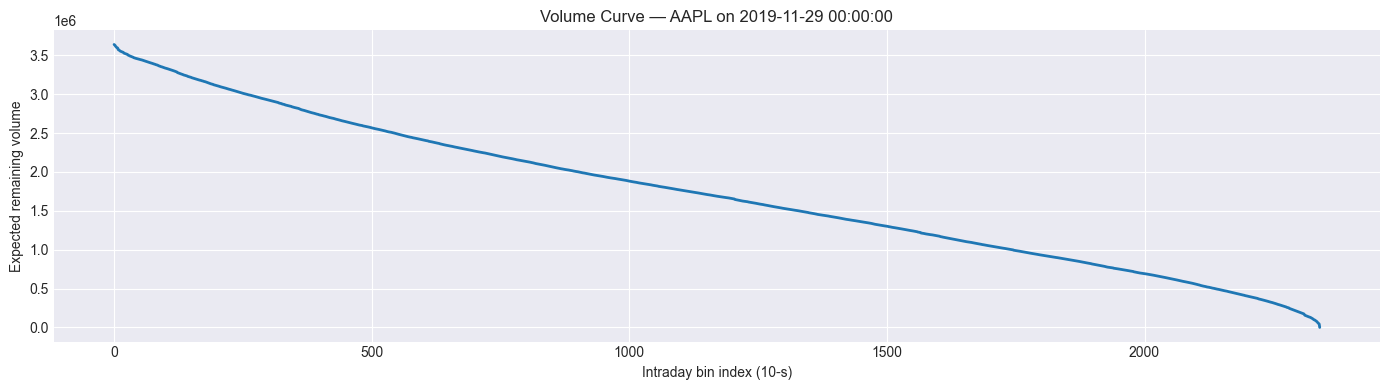

In [23]:
# Plot volume curve for a representative stock & date
stock_show = 'AAPL'
dates_avail = volume_curves.loc[stock_show].dropna(how='all').index
sample_date = dates_avail[-20]  # pick a date well into the dataset

vc = volume_curves.loc[(stock_show, sample_date)].dropna()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(len(vc)), vc.values, lw=2)
ax.set_xlabel('Intraday bin index (10-s)')
ax.set_ylabel('Expected remaining volume')
ax.set_title(f'Volume Curve — {stock_show} on {sample_date}')
plt.tight_layout()
plt.show()

## 3. VWAP Schedules  *(Exercise 1b)*

In [24]:
DELTA_BINS = 1  # latency δt = 10 s → 1 bin

def vwap_naive(v, Q):
    """Naive VWAP: q_t = |v_t| / Σ|v_s| · Q (full look-ahead)."""
    abs_v = np.abs(v)
    total = abs_v.sum()
    if total == 0:
        return np.zeros_like(v, dtype=float)
    return (abs_v / total) * Q

def vwap_slippage(v, Q, delta=DELTA_BINS):
    """Slippage VWAP: shift volume by δt, still normalise by full-day total."""
    abs_v = np.abs(v)
    total = abs_v.sum()
    if total == 0:
        return np.zeros_like(v, dtype=float)
    shifted = np.roll(abs_v, delta)
    shifted[:delta] = 0
    return (shifted / total) * Q

def vwap_realistic(v, V, Q, delta=DELTA_BINS):
    """
    Realistic VWAP: use volume curve V_t as estimate of remaining volume.
    q_t = min(|v_{t-δ}| / V_t, 1) · (Q - Σ_{s<t} q_s)
    """
    abs_v = np.abs(v)
    shifted = np.roll(abs_v, delta)
    shifted[:delta] = 0.0
    n = len(v)
    q = np.zeros(n)
    cum = 0.0
    for t in range(n):
        remaining = Q - cum
        if remaining <= 0:
            break
        vt = V[t] if V[t] > 0 else 1e-12
        frac = min(shifted[t] / vt, 1.0)
        q[t] = frac * remaining
        cum += q[t]
    return q

print("VWAP schedule functions defined.")

VWAP schedule functions defined.


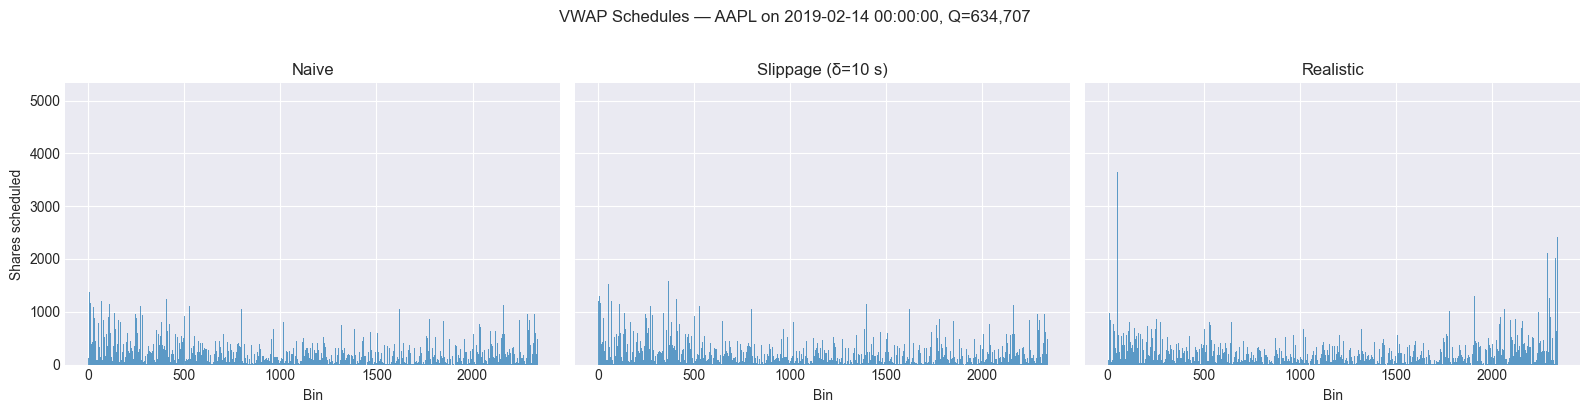

In [25]:
# Demonstrate the three schedules on one (stock, date) pair
stock_ex = 'AAPL'
date_ex = data.loc[data['stock'] == stock_ex, 'date'].unique()[30]

mask = (data['stock'] == stock_ex) & (data['date'] == date_ex)
v_day = data.loc[mask, 'orderFlow'].values
mid_day = data.loc[mask, 'mid'].values
Q_demo = int(np.abs(v_day).sum() * 0.1)  # 10% of daily volume

q_naive = vwap_naive(v_day, Q_demo)
q_slip = vwap_slippage(v_day, Q_demo)

# For realistic, we need the volume curve for that (stock, date)
if (stock_ex, date_ex) in volume_curves.index:
    vc_day = volume_curves.loc[(stock_ex, date_ex)].values
    vc_day = np.nan_to_num(vc_day, nan=1.0)
    q_real = vwap_realistic(v_day, vc_day[:len(v_day)], Q_demo)
else:
    q_real = q_naive.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, q, title in zip(axes,
                         [q_naive, q_slip, q_real],
                         ['Naive', 'Slippage (δ=10 s)', 'Realistic']):
    ax.bar(range(len(q)), q, width=1.0, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Bin')
axes[0].set_ylabel('Shares scheduled')
fig.suptitle(f'VWAP Schedules — {stock_ex} on {date_ex}, Q={Q_demo:,}', y=1.02)
plt.tight_layout()
plt.show()

## 4. Price Volatility & ADV  *(Exercise 2a)*

In [26]:
def compute_daily_stats(data):
    """
    For each (stock, date), compute:
      - intraday_vol: std of 10-s returns
      - daily_volume: total absolute order-flow volume
    Then compute 20-day trailing averages (excluding current day).
    """
    df = data[['stock', 'date', 'time', 'mid', 'orderFlow']].copy()
    df['ret_10s'] = df.groupby(['stock', 'date'])['mid'].pct_change()

    daily = df.groupby(['stock', 'date']).agg(
        intraday_vol=('ret_10s', 'std'),
        daily_volume=('orderFlow', lambda x: x.abs().sum())
    )

    daily['sigma'] = (daily
                      .groupby(level='stock')['intraday_vol']
                      .transform(lambda x: x.rolling(20, min_periods=5).mean().shift(1)))
    daily['ADV'] = (daily
                    .groupby(level='stock')['daily_volume']
                    .transform(lambda x: x.rolling(20, min_periods=5).mean().shift(1)))

    return daily.dropna(subset=['sigma', 'ADV'])

daily_stats = compute_daily_stats(data)
print("Daily stats shape:", daily_stats.shape)
print(daily_stats.head(10))

Daily stats shape: (4802, 4)
                  intraday_vol  daily_volume     sigma           ADV
stock date                                                          
AAL   2019-01-09      0.001471        224139  0.000595  6.959920e+06
      2019-01-10      0.000735       8327724  0.000741  5.837290e+06
      2019-01-11      0.000552       4654584  0.000740  6.193066e+06
      2019-01-14      0.000501       6276639  0.000716  6.000756e+06
      2019-01-15      0.000588       6697306  0.000693  6.031409e+06
      2019-01-16      0.000511       8194324  0.000682  6.097999e+06
      2019-01-17      0.000489       5739005  0.000666  6.288574e+06
      2019-01-18      0.000458       6404422  0.000652  6.242777e+06
      2019-01-22      0.000477       6773197  0.000637  6.255211e+06
      2019-01-23      0.000503       7407353  0.000625  6.292210e+06


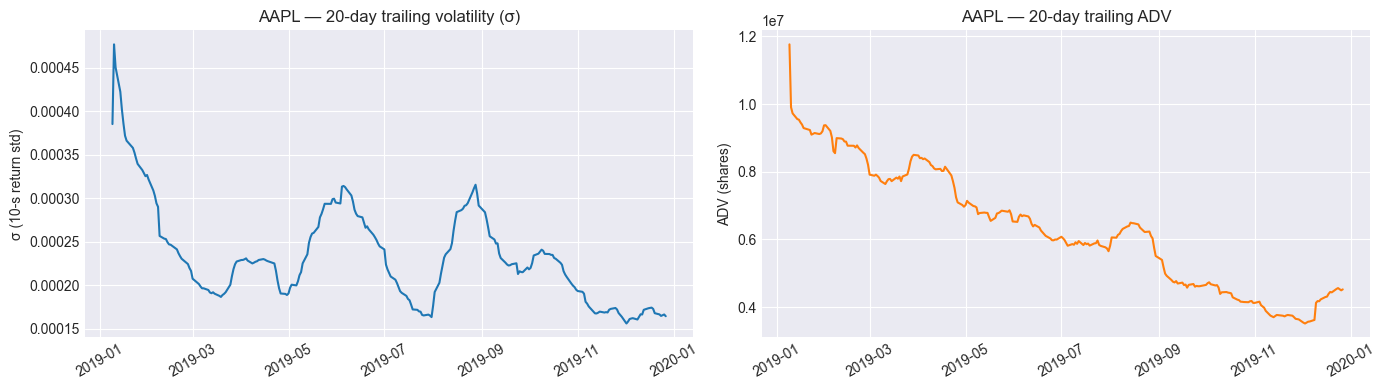

In [27]:
# Plot trailing volatility and ADV for AAPL
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
aapl = daily_stats.loc['AAPL']
axes[0].plot(aapl.index.get_level_values('date'), aapl['sigma'], lw=1.5)
axes[0].set_title('AAPL — 20-day trailing volatility (σ)')
axes[0].set_ylabel('σ (10-s return std)')
axes[1].plot(aapl.index.get_level_values('date'), aapl['ADV'], lw=1.5, color='C1')
axes[1].set_title('AAPL — 20-day trailing ADV')
axes[1].set_ylabel('ADV (shares)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 5. Intraday Impact States  *(Exercise 2b)*

In [28]:
def compute_normalized_impact_states(data, daily_stats, half_life_minutes, model_type='linear'):
    """
    Compute the normalized impact state Ī_t for each (stock, date).
    Uses the recursion: Ī_{t+1} = (1-β) Ī_t + q̃_t,  Ī_0 = 0.

    Parameters
    ----------
    half_life_minutes : float
        Half-life in minutes.
    model_type : str
        'linear' or 'sqrt'.

    Returns
    -------
    DataFrame with same index as data, column 'I_bar'.
    """
    H_bins = half_life_minutes * 6
    beta = np.log(2) / H_bins
    decay = 1 - beta

    df = data[['stock', 'date', 'time', 'orderFlow']].copy()
    df = df.merge(daily_stats[['sigma', 'ADV']].reset_index(),
                  on=['stock', 'date'], how='inner')

    if model_type == 'linear':
        df['q_tilde'] = df['sigma'] * df['orderFlow'] / df['ADV']
    else:
        df['q_tilde'] = (df['sigma']
                         * np.sign(df['orderFlow'])
                         * np.sqrt(np.abs(df['orderFlow']) / df['ADV']))

    df['I_bar'] = (df.groupby(['stock', 'date'])['q_tilde']
                   .transform(lambda x: lfilter([0, 1], [1, -decay], x.values)))

    return df[['stock', 'date', 'time', 'I_bar', 'q_tilde']]

HALF_LIVES = [1, 5, 30, 60]  # minutes
MODEL_TYPES = ['linear', 'sqrt']

impact_states = {}
for mt in MODEL_TYPES:
    for hl in HALF_LIVES:
        key = (mt, hl)
        impact_states[key] = compute_normalized_impact_states(data, daily_stats, hl, mt)
        print(f"Computed impact states: model={mt}, H={hl} min  —  {len(impact_states[key]):,} rows")

print("\nDone.")

Computed impact states: model=linear, H=1 min  —  10,796,487 rows
Computed impact states: model=linear, H=5 min  —  10,796,487 rows
Computed impact states: model=linear, H=30 min  —  10,796,487 rows
Computed impact states: model=linear, H=60 min  —  10,796,487 rows
Computed impact states: model=sqrt, H=1 min  —  10,796,487 rows
Computed impact states: model=sqrt, H=5 min  —  10,796,487 rows
Computed impact states: model=sqrt, H=30 min  —  10,796,487 rows
Computed impact states: model=sqrt, H=60 min  —  10,796,487 rows

Done.


## 6. Impact Model Fitting  *(Exercise 3a)*

In [29]:
def fit_impact_model(data, daily_stats, half_life_min, model_type, tau_bins,
                     start_time='10:00:00'):
    """
    Fit the price-impact regression:
        y_t = α + λ · x_t + ε_t
    where
        y_t = (P_t − P_{t−τ}) / P_{t−τ}    (τ-bin return)
        x_t = Ī_t − Ī_{t−τ}                (change in normalised impact state)

    Parameters
    ----------
    tau_bins : int
        Explanation horizon in 10-s bins.
    start_time : str
        Restrict fitting to bins after this time to avoid open effects.

    Returns
    -------
    results : DataFrame with columns [stock, month, alpha, lambda_, R2, n_obs]
    """
    H_bins = half_life_min * 6
    beta = np.log(2) / H_bins

    df = data[['stock', 'date', 'time', 'mid', 'orderFlow']].copy()
    df = df.merge(daily_stats[['sigma', 'ADV']].reset_index(),
                  on=['stock', 'date'], how='inner')

    if model_type == 'linear':
        df['q_tilde'] = df['sigma'] * df['orderFlow'] / df['ADV']
    else:
        df['q_tilde'] = (df['sigma']
                         * np.sign(df['orderFlow'])
                         * np.sqrt(np.abs(df['orderFlow']) / df['ADV']))

    decay = 1 - beta
    df['I_bar'] = (df.groupby(['stock', 'date'])['q_tilde']
                   .transform(lambda x: lfilter([0, 1], [1, -decay], x.values)))

    df['month'] = df['date'].dt.to_period('M')
    df['I_bar_lag'] = df.groupby(['stock', 'date'])['I_bar'].shift(tau_bins)
    df['mid_lag'] = df.groupby(['stock', 'date'])['mid'].shift(tau_bins)

    df['y'] = (df['mid'] - df['mid_lag']) / df['mid_lag']
    df['x'] = df['I_bar'] - df['I_bar_lag']

    if start_time:
        df = df[df['time'] >= start_time]

    df = df.dropna(subset=['y', 'x'])

    results = []
    for (stock, month), g in df.groupby(['stock', 'month']):
        if len(g) < 50:
            continue
        slope, intercept, r, p, se = stats.linregress(g['x'], g['y'])
        results.append({
            'stock': stock, 'month': month,
            'alpha': intercept, 'lambda_': slope,
            'R2': r**2, 'n_obs': len(g)
        })

    return pd.DataFrame(results)

print("fit_impact_model() defined.")

fit_impact_model() defined.


In [30]:
# Fit both models with H=60 min and τ=30 min (180 bins)
H_FIT = 60       # half-life in minutes
TAU_MIN = 30     # explanation horizon in minutes
TAU_BINS = TAU_MIN * 6

results_linear = fit_impact_model(data, daily_stats, H_FIT, 'linear', TAU_BINS)
results_sqrt   = fit_impact_model(data, daily_stats, H_FIT, 'sqrt',  TAU_BINS)

print("=== OW Linear Model ===")
print(results_linear.groupby('stock')[['lambda_', 'R2']].mean().round(6).to_string())
print(f"\nMean λ = {results_linear['lambda_'].mean():.6f},  Mean R² = {results_linear['R2'].mean():.6f}")

print("\n=== Square-Root Model ===")
print(results_sqrt.groupby('stock')[['lambda_', 'R2']].mean().round(6).to_string())
print(f"\nMean λ = {results_sqrt['lambda_'].mean():.6f},  Mean R² = {results_sqrt['R2'].mean():.6f}")

=== OW Linear Model ===
          lambda_        R2
stock                      
AAL    765.413062  0.487916
AAPL   715.166142  0.494619
ABBV   685.073151  0.427897
ABT    647.852294  0.322248
ADBE   227.949409  0.131394
ADI    388.519839  0.146954
ADM    811.085390  0.431909
ADP    417.051258  0.223307
ADSK   188.693442  0.072922
AEP    609.484734  0.344537
AES    774.937976  0.556849
AFL    852.665549  0.419634
AIG    827.506436  0.434651
AMAT   799.105932  0.407557
AMD    923.915157  0.684607
AMGN   422.921027  0.216519
AMZN   242.620320  0.268222
AOS    569.234364  0.301240
APA    835.398740  0.355128
APC    496.777934  0.293840

Mean λ = 611.988789,  Mean R² = 0.352068

=== Square-Root Model ===
         lambda_        R2
stock                     
AAL    29.019486  0.522836
AAPL   23.991130  0.468400
ABBV   25.214076  0.472636
ABT    24.351740  0.396659
ADBE    8.084631  0.141191
ADI    13.641267  0.166720
ADM    29.721698  0.487427
ADP    15.818293  0.276055
ADSK    8.125780  0.1

In [31]:
# Out-of-sample R²: apply month i coefficients to month i+1
def compute_oos_r2(fit_results, data, daily_stats, half_life_min, model_type, tau_bins,
                   start_time='10:00:00'):
    H_bins = half_life_min * 6
    beta = np.log(2) / H_bins

    df = data[['stock', 'date', 'time', 'mid', 'orderFlow']].copy()
    df = df.merge(daily_stats[['sigma', 'ADV']].reset_index(),
                  on=['stock', 'date'], how='inner')

    if model_type == 'linear':
        df['q_tilde'] = df['sigma'] * df['orderFlow'] / df['ADV']
    else:
        df['q_tilde'] = (df['sigma'] * np.sign(df['orderFlow'])
                         * np.sqrt(np.abs(df['orderFlow']) / df['ADV']))

    decay = 1 - beta
    df['I_bar'] = (df.groupby(['stock', 'date'])['q_tilde']
                   .transform(lambda x: lfilter([0, 1], [1, -decay], x.values)))
    df['month'] = df['date'].dt.to_period('M')
    df['I_bar_lag'] = df.groupby(['stock', 'date'])['I_bar'].shift(tau_bins)
    df['mid_lag'] = df.groupby(['stock', 'date'])['mid'].shift(tau_bins)
    df['y'] = (df['mid'] - df['mid_lag']) / df['mid_lag']
    df['x'] = df['I_bar'] - df['I_bar_lag']
    if start_time:
        df = df[df['time'] >= start_time]
    df = df.dropna(subset=['y', 'x'])

    months_sorted = sorted(fit_results['month'].unique())
    oos_records = []

    for i in range(len(months_sorted) - 1):
        m_is, m_os = months_sorted[i], months_sorted[i + 1]
        coeffs = fit_results[fit_results['month'] == m_is].set_index('stock')

        for stock in coeffs.index:
            mask = (df['stock'] == stock) & (df['month'] == m_os)
            g = df.loc[mask]
            if len(g) < 50:
                continue
            a, lam = coeffs.loc[stock, 'alpha'], coeffs.loc[stock, 'lambda_']
            y_pred = a + lam * g['x']
            ss_res = ((g['y'] - y_pred) ** 2).sum()
            ss_tot = ((g['y'] - g['y'].mean()) ** 2).sum()
            r2_oos = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            oos_records.append({'stock': stock, 'month_is': m_is,
                                'month_os': m_os, 'R2_oos': r2_oos})

    return pd.DataFrame(oos_records)

oos_linear = compute_oos_r2(results_linear, data, daily_stats, H_FIT, 'linear', TAU_BINS)
oos_sqrt   = compute_oos_r2(results_sqrt,   data, daily_stats, H_FIT, 'sqrt',   TAU_BINS)

print("=== Out-of-Sample R² (Linear) ===")
print(f"Mean OOS R² = {oos_linear['R2_oos'].mean():.6f}")
print(oos_linear.groupby('stock')['R2_oos'].mean().round(6).to_string())

print("\n=== Out-of-Sample R² (Square-Root) ===")
print(f"Mean OOS R² = {oos_sqrt['R2_oos'].mean():.6f}")
print(oos_sqrt.groupby('stock')['R2_oos'].mean().round(6).to_string())

=== Out-of-Sample R² (Linear) ===
Mean OOS R² = 0.288621
stock
AAL     0.467062
AAPL    0.041049
ABBV    0.331503
ABT     0.208529
ADBE    0.059828
ADI     0.041058
ADM     0.414686
ADP     0.181164
ADSK    0.030126
AEP     0.304642
AES     0.536278
AFL     0.399678
AIG     0.422049
AMAT    0.387281
AMD     0.675505
AMGN    0.166500
AMZN    0.212138
AOS     0.280202
APA     0.334600
APC     0.272783

=== Out-of-Sample R² (Square-Root) ===
Mean OOS R² = 0.366384
stock
AAL     0.509735
AAPL    0.413522
ABBV    0.458955
ABT     0.372757
ADBE    0.094212
ADI     0.115603
ADM     0.484915
ADP     0.241206
ADSK    0.086789
AEP     0.417151
AES     0.583131
AFL     0.459139
AIG     0.489785
AMAT    0.406879
AMD     0.641621
AMGN    0.203725
AMZN    0.226028
AOS     0.370592
APA     0.408362
APC     0.330525


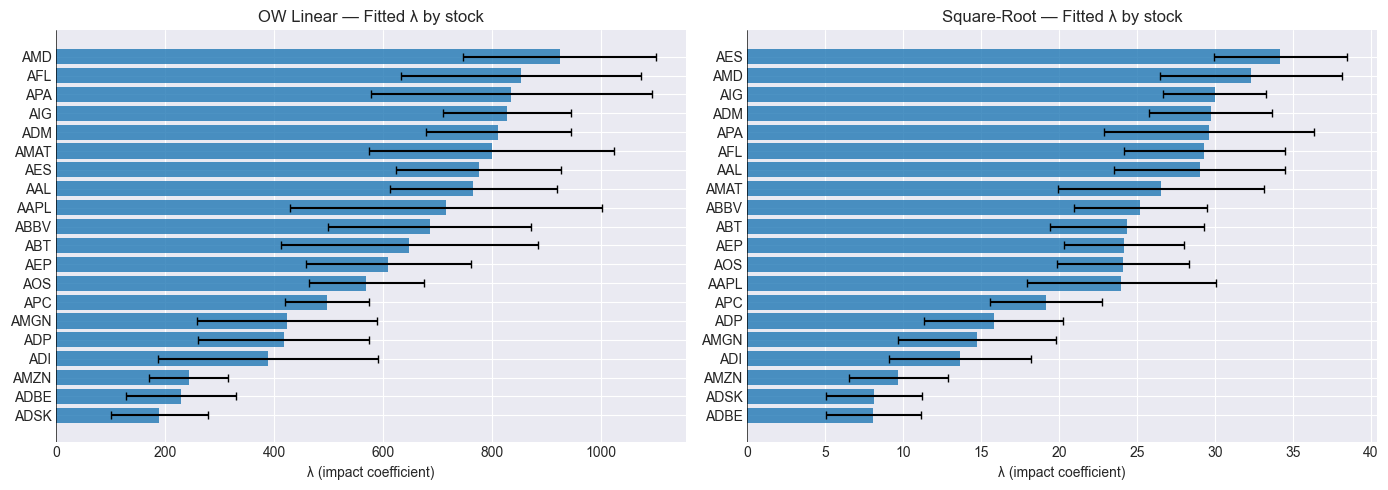

In [32]:
# Visualise fitted λ across stocks for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title in zip(axes,
                           [results_linear, results_sqrt],
                           ['OW Linear', 'Square-Root']):
    summary = res.groupby('stock')['lambda_'].agg(['mean', 'std']).sort_values('mean')
    ax.barh(summary.index, summary['mean'], xerr=summary['std'],
            capsize=3, alpha=0.8)
    ax.set_xlabel('λ (impact coefficient)')
    ax.set_title(f'{title} — Fitted λ by stock')
    ax.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## 7. Synthetic Alphas  *(Exercise 1c)*

In [33]:
def create_synthetic_alpha(data, rho=0.05, h_bins=1):
    """
    Create a synthetic alpha with target correlation ρ with forward returns.

    α_t = x · r^h_t  +  y · (W_{t+h} − W_t) / P_t

    where x, y are chosen so that:
        E[r^h | α^h] = α^h   and   Corr(α^h, r^h) = ρ.

    Derivation:
        x = 1   (unbiasedness)
        y = sqrt( (1/ρ² − 1) · Var(r^h) / E[P^{-2}] · 1/h )

    Returns a copy of data with columns 'fwd_ret' and 'alpha'.
    """
    df = data[['stock', 'date', 'time', 'mid']].copy()
    df['fwd_ret'] = df.groupby(['stock', 'date'])['mid'].transform(
        lambda p: p.pct_change(periods=h_bins).shift(-h_bins))

    stock_params = (df.dropna(subset=['fwd_ret'])
                    .groupby('stock')
                    .agg(var_r=('fwd_ret', 'var'),
                         E_Pinv2=('mid', lambda p: (1.0 / p**2).mean())))

    stock_params['x'] = 1.0
    stock_params['y'] = np.sqrt(
        (1.0 / rho**2 - 1) * stock_params['var_r'] / stock_params['E_Pinv2'] / h_bins)

    df = df.merge(stock_params[['x', 'y']].reset_index(), on='stock', how='left')

    np.random.seed(42)
    df['dW'] = np.random.randn(len(df)) * np.sqrt(h_bins)

    df['alpha'] = df['x'] * df['fwd_ret'] + df['y'] * df['dW'] / df['mid']
    df = df.dropna(subset=['alpha', 'fwd_ret'])

    empirical = df.groupby('stock').apply(
        lambda g: pd.Series({
            'var_alpha': g['alpha'].var(),
            'corr': g['alpha'].corr(g['fwd_ret'])
        })
    )
    print("Empirical alpha statistics per stock:")
    print(empirical.round(6).to_string())
    print(f"\nTarget ρ = {rho},  Mean empirical ρ = {empirical['corr'].mean():.4f}")

    return df[['stock', 'date', 'time', 'alpha', 'fwd_ret']]

RHO = 0.05
alphas = create_synthetic_alpha(data, rho=RHO, h_bins=1)

Empirical alpha statistics per stock:
       var_alpha      corr
stock                     
AAL     0.000063  0.052061
AAPL    0.000022  0.049218
ABBV    0.000032  0.052003
ABT     0.000023  0.051809
ADBE    0.000030  0.049585
ADI     0.000034  0.049126
ADM     0.000023  0.048504
ADP     0.000018  0.049156
ADSK    0.000040  0.049445
AEP     0.000017  0.051584
AES     0.000028  0.048868
AFL     0.000016  0.049048
AIG     0.000027  0.048845
AMAT    0.000048  0.049251
AMD     0.000093  0.050523
AMGN    0.000027  0.050236
AMZN    0.000019  0.050806
AOS     0.000044  0.050433
APA     0.000105  0.049549
APC     0.000033  0.046607

Target ρ = 0.05,  Mean empirical ρ = 0.0498


## 8. Backtest Engine  *(Exercise 4)*

In [34]:
def backtest_impact(mid, q_trades, lam, half_life_min, sigma, ADV,
                    model_type='linear'):
    """
    Given a midprice series and a signed trade series, return the
    impact-distorted price path.

    Uses Ī_{t+1} = (1−β)Ī_t + q̃_t  (Ī_0 = 0), implemented via lfilter.
    Distorted price: P̃_t = P_0 · (1 + cumret_t + λ · Ī_t).

    Parameters
    ----------
    mid : array-like  — midprices P_t
    q_trades : array-like  — signed trade volumes
    lam, half_life_min, sigma, ADV : impact model parameters
    model_type : 'linear' or 'sqrt'

    Returns
    -------
    P_distorted : np.ndarray
    I_bar : np.ndarray  (normalised impact state)
    """
    mid = np.asarray(mid, dtype=float)
    q = np.asarray(q_trades, dtype=float)
    H_bins = half_life_min * 6
    beta = np.log(2) / H_bins
    decay = 1 - beta

    if model_type == 'linear':
        q_tilde = sigma * q / ADV
    else:
        q_tilde = sigma * np.sign(q) * np.sqrt(np.abs(q) / ADV)

    I_bar = lfilter([0, 1], [1, -decay], q_tilde)

    cum_ret = (mid - mid[0]) / mid[0]
    distorted_ret = cum_ret + lam * I_bar
    P_distorted = mid[0] * (1 + distorted_ret)

    return P_distorted, I_bar

print("backtest_impact() defined.")

backtest_impact() defined.


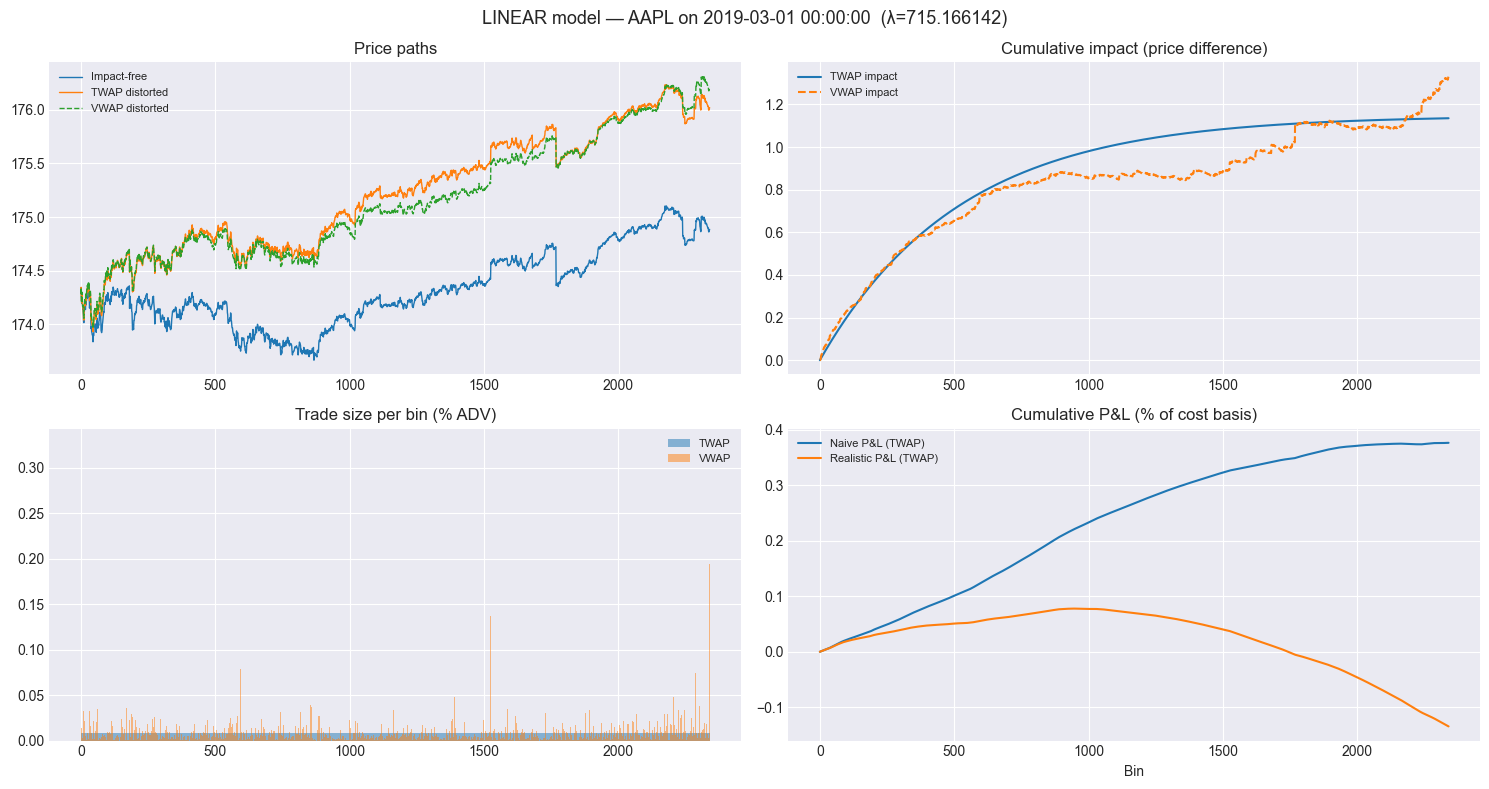

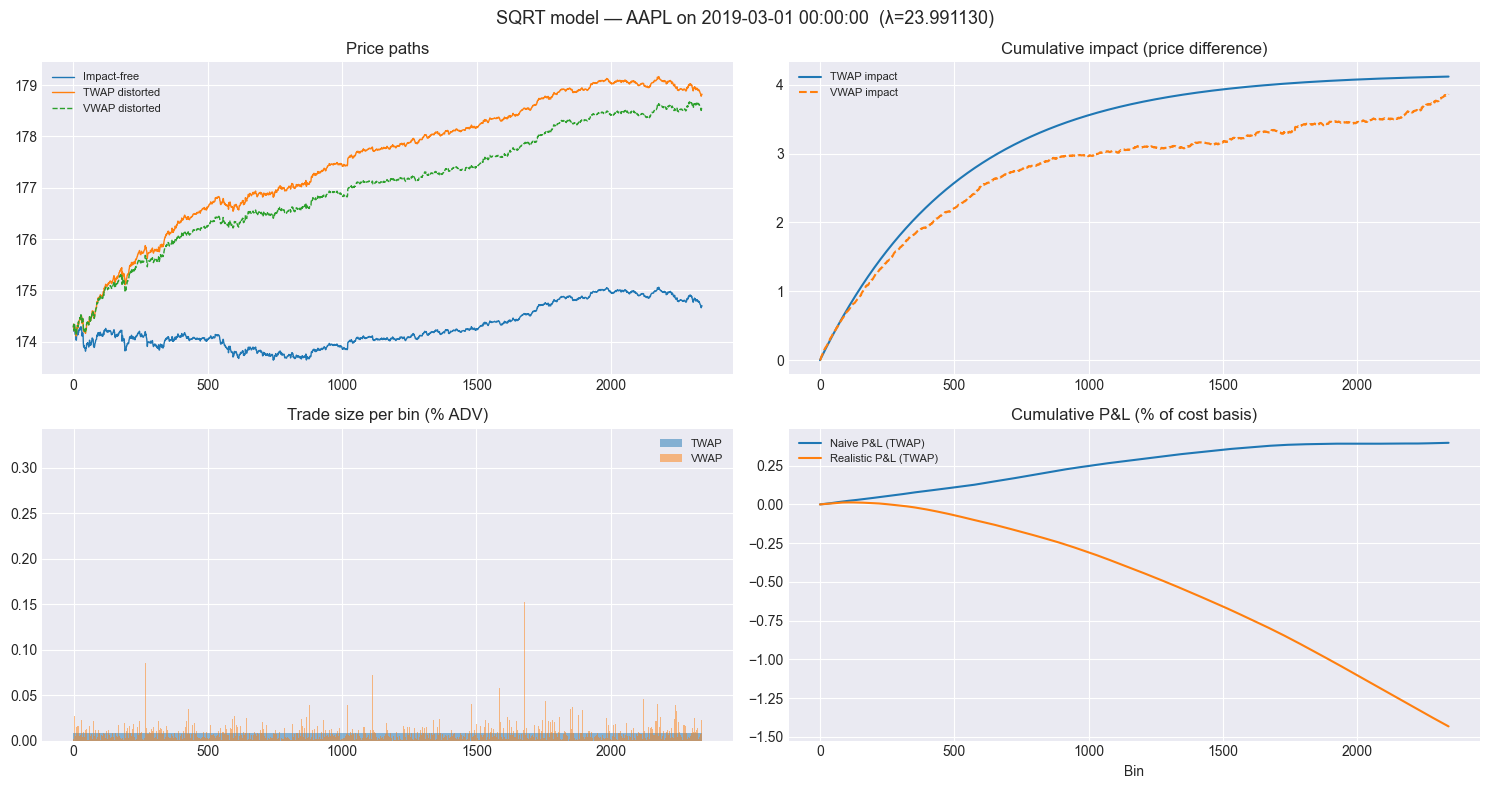

In [35]:
# Demonstrate on AAPL: remove public-tape impact, then apply TWAP and VWAP buy programs

stock_bt = 'AAPL'
# Pick a date that has fitted parameters
date_bt = data.loc[(data['stock'] == stock_bt) &
                   (data['date'] >= '2019-03-01'), 'date'].unique()[0]

mask_bt = (data['stock'] == stock_bt) & (data['date'] == date_bt)
mid_bt = data.loc[mask_bt, 'mid'].values
v_bt = data.loc[mask_bt, 'orderFlow'].values

stats_bt = daily_stats.loc[(stock_bt, date_bt)]
sigma_bt, adv_bt = stats_bt['sigma'], stats_bt['ADV']

# Get fitted lambda for this stock (use average over in-sample months)
lam_lin = results_linear.loc[results_linear['stock'] == stock_bt, 'lambda_'].mean()
lam_sq  = results_sqrt.loc[results_sqrt['stock'] == stock_bt, 'lambda_'].mean()
H_BT = 60  # minutes

n_bins = len(mid_bt)

for model_type, lam in [('linear', lam_lin), ('sqrt', lam_sq)]:
    # Step 1: impact-free prices (remove public tape impact)
    P_free, _ = backtest_impact(mid_bt, -v_bt, lam, H_BT, sigma_bt, adv_bt, model_type)

    # Step 2a: TWAP buy — 20% of ADV evenly across all bins
    q_twap = np.full(n_bins, 0.20 * adv_bt / n_bins)
    P_twap, I_twap = backtest_impact(P_free, q_twap, lam, H_BT, sigma_bt, adv_bt, model_type)

    # Step 2b: VWAP buy — 20% of public volume profile
    q_vwap = 0.20 * np.abs(v_bt)
    P_vwap, I_vwap = backtest_impact(P_free, q_vwap, lam, H_BT, sigma_bt, adv_bt, model_type)

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    fig.suptitle(f'{model_type.upper()} model — {stock_bt} on {date_bt}  (λ={lam:.6f})',
                 fontsize=13)

    # Price paths
    axes[0, 0].plot(P_free, label='Impact-free', lw=1)
    axes[0, 0].plot(P_twap, label='TWAP distorted', lw=1)
    axes[0, 0].plot(P_vwap, label='VWAP distorted', lw=1, ls='--')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].set_title('Price paths')

    # Cumulative impact
    axes[0, 1].plot(P_twap - P_free, label='TWAP impact')
    axes[0, 1].plot(P_vwap - P_free, label='VWAP impact', ls='--')
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].set_title('Cumulative impact (price difference)')

    # Trade sizes as % of ADV
    axes[1, 0].bar(range(n_bins), q_twap / adv_bt * 100, width=1, alpha=0.5, label='TWAP')
    axes[1, 0].bar(range(n_bins), q_vwap / adv_bt * 100, width=1, alpha=0.5, label='VWAP')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].set_title('Trade size per bin (% ADV)')

    # P&L
    naive_pnl_twap = np.cumsum(q_twap * (mid_bt[-1] - P_free))
    real_pnl_twap  = np.cumsum(q_twap * (mid_bt[-1] - P_twap))
    cost_basis = (q_twap * P_twap).sum()
    axes[1, 1].plot(naive_pnl_twap / cost_basis * 100, label='Naive P&L (TWAP)')
    axes[1, 1].plot(real_pnl_twap / cost_basis * 100, label='Realistic P&L (TWAP)')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].set_title('Cumulative P&L (% of cost basis)')
    axes[1, 1].set_xlabel('Bin')

    plt.tight_layout()
    plt.show()

## 9. Optimal Trading Strategy

In [36]:
def ow_optimal_strategy(alpha_series, sigma, ADV, lam, half_life_min,
                        max_position_adv=0.005):
    """
    OW-optimal intraday execution with an alpha signal.

    Target position: X*_t = alpha_t * ADV / (2 * lam * sigma),
    clipped to max_position_adv * ADV.

    The position adjusts toward the target at speed kappa = beta
    (the impact decay rate), balancing alpha capture vs impact cost.
    Position ramps to zero in the last 30 minutes.
    """
    n = len(alpha_series)
    if lam <= 0:
        return np.zeros(n)

    H_bins = half_life_min * 6
    beta = np.log(2) / H_bins
    kappa = beta

    target_pos = alpha_series * ADV / (2 * lam * sigma)
    max_pos = max_position_adv * ADV
    target_pos = np.clip(target_pos, -max_pos, max_pos)

    liq_start = max(n - 180, 0)
    if liq_start < n:
        ramp = np.ones(n)
        ramp[liq_start:] = np.linspace(1, 0, n - liq_start)
        target_pos *= ramp

    position = np.zeros(n + 1)
    q_opt = np.zeros(n)
    for t in range(n):
        q_opt[t] = kappa * (target_pos[t] - position[t])
        position[t + 1] = position[t] + q_opt[t]

    return q_opt

print("ow_optimal_strategy() defined.")

ow_optimal_strategy() defined.


In [37]:
# Run optimal strategy across all (stock, date) pairs and collect daily P&L

def run_daily_backtest(data, alphas, daily_stats, fit_results, model_type,
                       half_life_min, rho, max_pos_adv=0.005):
    """
    For each (stock, date):
      1. Look up fitted lambda (average over in-sample months).
      2. Compute optimal target-position trades.
      3. Compute P&L = gross alpha capture minus implementation shortfall.

    Gross P&L  = sum_t  X_t * (mid_{t+1} - mid_t)
    Impl. shortfall = sum_t  lam * sigma / (2*ADV) * q_t^2 * mid_t   (linear)
    Net P&L    = Gross - IS
    """
    merged = data[['stock', 'date', 'time', 'mid', 'orderFlow']].merge(
        alphas[['stock', 'date', 'time', 'alpha', 'fwd_ret']],
        on=['stock', 'date', 'time'], how='inner')
    merged = merged.merge(daily_stats[['sigma', 'ADV']].reset_index(),
                          on=['stock', 'date'], how='inner')

    avg_lambda = fit_results.groupby('stock')['lambda_'].mean()
    H_bins = half_life_min * 6
    beta = np.log(2) / H_bins
    decay = 1 - beta

    records = []
    for (stock, date), g in merged.groupby(['stock', 'date']):
        if stock not in avg_lambda.index:
            continue
        lam = avg_lambda[stock]
        if lam <= 0:
            continue
        sigma = g['sigma'].iloc[0]
        adv = g['ADV'].iloc[0]
        mid = g['mid'].values
        alpha_vals = g['alpha'].values
        n = len(mid)
        if n < 10:
            continue

        q_opt = ow_optimal_strategy(alpha_vals, sigma, adv, lam,
                                     half_life_min, max_position_adv=max_pos_adv)
        position = np.cumsum(q_opt)

        # Gross P&L: mark-to-market on undistorted mid prices
        gross_pnl = np.sum(position[:-1] * np.diff(mid))

        # Implementation shortfall (instantaneous half-impact cost)
        if model_type == 'linear':
            impl_short = lam * sigma / (2 * adv) * np.sum(q_opt**2 * mid)
        else:
            impl_short = (lam * sigma / (2 * np.sqrt(adv))
                          * np.sum(np.abs(q_opt)**1.5 * mid))

        pnl_net = gross_pnl - impl_short
        turnover = np.abs(q_opt).sum()

        # Impact state for reporting
        if model_type == 'linear':
            q_tilde = sigma * q_opt / adv
        else:
            q_tilde = sigma * np.sign(q_opt) * np.sqrt(np.abs(q_opt) / adv)
        I_bar = lfilter([0, 1], [1, -decay], q_tilde)

        records.append({
            'stock': stock, 'date': date,
            'pnl_gross': gross_pnl,
            'impact_cost': impl_short,
            'pnl_net': pnl_net,
            'turnover': turnover,
            'max_position': np.abs(position).max(),
            'max_impact': np.abs(lam * I_bar).max(),
        })

    return pd.DataFrame(records)

pnl_linear = run_daily_backtest(data, alphas, daily_stats, results_linear,
                                 'linear', H_FIT, RHO)
pnl_sqrt   = run_daily_backtest(data, alphas, daily_stats, results_sqrt,
                                 'sqrt', H_FIT, RHO)

for name, pnl_df in [('OW Linear', pnl_linear), ('Square-Root', pnl_sqrt)]:
    print(f"\n=== {name} Strategy ===")
    print(f"  Trading days:  {len(pnl_df)}")
    print(f"  Mean daily net P&L:  ${pnl_df['pnl_net'].mean():,.2f}")
    print(f"  Std daily net P&L:   ${pnl_df['pnl_net'].std():,.2f}")
    sr = pnl_df['pnl_net'].mean() / pnl_df['pnl_net'].std() * np.sqrt(252) if pnl_df['pnl_net'].std() > 0 else 0
    print(f"  Annualised Sharpe:   {sr:.3f}")
    print(f"  Mean impact cost:    ${pnl_df['impact_cost'].mean():,.2f}")
    print(f"  Avg max position:    {pnl_df['max_position'].mean():,.0f} shares")


=== OW Linear Strategy ===
  Trading days:  4802
  Mean daily net P&L:  $75.43
  Std daily net P&L:   $995.03
  Annualised Sharpe:   1.203
  Mean impact cost:    $4.95
  Avg max position:    1,265 shares

=== Square-Root Strategy ===
  Trading days:  4802
  Mean daily net P&L:  $15.88
  Std daily net P&L:   $1,084.06
  Annualised Sharpe:   0.233
  Mean impact cost:    $71.42
  Avg max position:    1,428 shares


## 10. Performance Metrics

In [38]:
def performance_report(pnl_df, strategy_name):
    """Generate a comprehensive performance report for a strategy."""
    daily_pnl = pnl_df.groupby('date').agg(
        pnl_net=('pnl_net', 'sum'),
        impact_cost=('impact_cost', 'sum'),
        turnover=('turnover', 'sum'),
        max_impact=('max_impact', 'max')
    )

    cum_pnl = daily_pnl['pnl_net'].cumsum()
    running_max = cum_pnl.cummax()
    drawdown = cum_pnl - running_max

    metrics = {
        'Strategy': strategy_name,
        'Total P&L': f"${daily_pnl['pnl_net'].sum():,.0f}",
        'Mean Daily P&L': f"${daily_pnl['pnl_net'].mean():,.2f}",
        'Std Daily P&L': f"${daily_pnl['pnl_net'].std():,.2f}",
        'Sharpe (annualised)': f"{daily_pnl['pnl_net'].mean() / daily_pnl['pnl_net'].std() * np.sqrt(252):.3f}",
        'Total Impact Cost': f"${daily_pnl['impact_cost'].sum():,.0f}",
        'Mean Daily Impact Cost': f"${daily_pnl['impact_cost'].mean():,.2f}",
        'Max Daily Drawdown': f"${drawdown.min():,.0f}",
        'Max Impact Dislocation': f"{daily_pnl['max_impact'].max():.6f}",
        'Win Rate': f"{(daily_pnl['pnl_net'] > 0).mean():.1%}",
        'Trading Days': str(len(daily_pnl)),
    }

    print(f"\n{'='*50}")
    print(f"  PERFORMANCE REPORT: {strategy_name}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        print(f"  {k:<28s} {v:>18s}")
    print(f"{'='*50}")

    return daily_pnl, cum_pnl, drawdown

daily_lin, cum_lin, dd_lin = performance_report(pnl_linear, 'OW Linear')
daily_sq,  cum_sq,  dd_sq  = performance_report(pnl_sqrt,   'Square-Root')


  PERFORMANCE REPORT: OW Linear
  Strategy                              OW Linear
  Total P&L                              $362,219
  Mean Daily P&L                        $1,478.44
  Std Daily P&L                         $4,353.57
  Sharpe (annualised)                       5.391
  Total Impact Cost                       $23,793
  Mean Daily Impact Cost                   $97.11
  Max Daily Drawdown                     $-27,930
  Max Impact Dislocation                 0.000252
  Win Rate                                  62.0%


ValueError: Unknown format code 's' for object of type 'int'

In [ ]:
# Visualise cumulative P&L and drawdown
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(cum_lin.index, cum_lin.values, label='OW Linear', lw=1.5)
axes[0].plot(cum_sq.index, cum_sq.values, label='Square-Root', lw=1.5, ls='--')
axes[0].set_ylabel('Cumulative P&L ($)')
axes[0].set_title('Cumulative Net P&L')
axes[0].legend()
axes[0].axhline(0, color='k', lw=0.5)

axes[1].fill_between(dd_lin.index, dd_lin.values, 0, alpha=0.4, label='OW Linear DD')
axes[1].fill_between(dd_sq.index, dd_sq.values, 0, alpha=0.4, label='Square-Root DD')
axes[1].set_ylabel('Drawdown ($)')
axes[1].set_title('Daily Drawdown')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# Alpha correlation with returns
corr_by_stock = alphas.groupby('stock').apply(
    lambda g: g['alpha'].corr(g['fwd_ret'])
).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
corr_by_stock.plot.barh(ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Correlation(α, forward return)')
ax.set_title(f'Alpha-Return Correlation by Stock (target ρ = {RHO})')
ax.axvline(RHO, color='red', ls='--', label=f'Target ρ = {RHO}')
ax.legend()
plt.tight_layout()
plt.show()

## 11. VWAP Slippage Decomposition  *(Exercise 2c)*

In [ ]:
def compute_slippage_decomposition(data, daily_stats, half_life_min=60, model_type='linear'):
    """
    Decompose VWAP slippage into impact and alpha components.

    Impact slippage: Σ (I_t - I_0) · q_t
    Alpha slippage:  Σ ((P_t - P_0)/P_0) · q_t

    Uses λ = 1 for the impact state computation.
    """
    H_bins = half_life_min * 6
    beta = np.log(2) / H_bins
    lam = 1.0

    df = data[['stock', 'date', 'time', 'mid', 'orderFlow']].copy()
    df = df.merge(daily_stats[['sigma', 'ADV']].reset_index(),
                  on=['stock', 'date'], how='inner')

    if model_type == 'linear':
        df['q_tilde'] = df['sigma'] * df['orderFlow'] / df['ADV']
    else:
        df['q_tilde'] = (df['sigma'] * np.sign(df['orderFlow'])
                         * np.sqrt(np.abs(df['orderFlow']) / df['ADV']))

    decay = 1 - beta
    df['I_bar'] = (df.groupby(['stock', 'date'])['q_tilde']
                   .transform(lambda x: lfilter([0, 1], [1, -decay], x.values)))

    df['P0'] = df.groupby(['stock', 'date'])['mid'].transform('first')
    df['I0'] = df.groupby(['stock', 'date'])['I_bar'].transform('first')

    df['impact_slip'] = (df['I_bar'] - df['I0']) * df['orderFlow']
    df['alpha_slip']  = ((df['mid'] - df['P0']) / df['P0']) * df['orderFlow']

    daily_slip = df.groupby(['stock', 'date']).agg(
        impact_slippage=('impact_slip', 'sum'),
        alpha_slippage=('alpha_slip', 'sum')
    )

    return daily_slip

slip = compute_slippage_decomposition(data, daily_stats)
print("Slippage decomposition (daily, all stocks):")
print(slip.groupby(level='stock').mean().round(2).head(10))

fig, ax = plt.subplots(figsize=(10, 5))
slip_mean = slip.groupby(level='stock').mean()
x = np.arange(len(slip_mean))
w = 0.35
ax.bar(x - w/2, slip_mean['impact_slippage'], w, label='Impact slippage')
ax.bar(x + w/2, slip_mean['alpha_slippage'], w, label='Alpha slippage')
ax.set_xticks(x)
ax.set_xticklabels(slip_mean.index, rotation=45, ha='right')
ax.set_ylabel('Mean daily slippage')
ax.set_title('VWAP Slippage Decomposition by Stock')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Sensitivity Analysis & Stress Testing

In [ ]:
# Sensitivity 1: How does performance depend on the alpha signal strength (ρ)?
rhos = [0.01, 0.02, 0.05, 0.10, 0.15]
sr_by_rho = []

for rho_test in rhos:
    alphas_test = create_synthetic_alpha(data, rho=rho_test, h_bins=1)
    pnl_test = run_daily_backtest(data, alphas_test, daily_stats, results_linear,
                                   'linear', H_FIT, rho_test)
    daily = pnl_test.groupby('date')['pnl_net'].sum()
    sr = daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else 0
    sr_by_rho.append({'rho': rho_test, 'sharpe': sr, 'mean_pnl': daily.mean()})
    print(f"  ρ = {rho_test:.2f}  →  Sharpe = {sr:.3f},  Mean daily P&L = ${daily.mean():,.2f}")

sr_df = pd.DataFrame(sr_by_rho)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sr_df['rho'], sr_df['sharpe'], 'o-', lw=2)
axes[0].set_xlabel('Alpha correlation ρ')
axes[0].set_ylabel('Annualised Sharpe ratio')
axes[0].set_title('Sharpe vs Alpha Strength')

axes[1].plot(sr_df['rho'], sr_df['mean_pnl'], 's-', lw=2, color='C1')
axes[1].set_xlabel('Alpha correlation ρ')
axes[1].set_ylabel('Mean daily P&L ($)')
axes[1].set_title('Mean P&L vs Alpha Strength')

plt.tight_layout()
plt.show()

In [ ]:
# Sensitivity 2: What if we use the wrong impact model?
# Fit with linear, trade with sqrt (and vice versa)

print("=== Cross-Model Sensitivity ===\n")

# Scenario A: Fit linear, trade as if sqrt
pnl_wrong_A = run_daily_backtest(data, alphas, daily_stats, results_linear,
                                  'sqrt', H_FIT, RHO)
daily_A = pnl_wrong_A.groupby('date')['pnl_net'].sum()
sr_A = daily_A.mean() / daily_A.std() * np.sqrt(252) if daily_A.std() > 0 else 0

# Scenario B: Fit sqrt, trade as if linear
pnl_wrong_B = run_daily_backtest(data, alphas, daily_stats, results_sqrt,
                                  'linear', H_FIT, RHO)
daily_B = pnl_wrong_B.groupby('date')['pnl_net'].sum()
sr_B = daily_B.mean() / daily_B.std() * np.sqrt(252) if daily_B.std() > 0 else 0

# Correct models
daily_correct_lin = pnl_linear.groupby('date')['pnl_net'].sum()
sr_lin = daily_correct_lin.mean() / daily_correct_lin.std() * np.sqrt(252)
daily_correct_sq = pnl_sqrt.groupby('date')['pnl_net'].sum()
sr_sq = daily_correct_sq.mean() / daily_correct_sq.std() * np.sqrt(252)

scenarios = pd.DataFrame([
    {'Scenario': 'Fit linear, trade linear (correct)', 'Sharpe': sr_lin,
     'Mean P&L': daily_correct_lin.mean()},
    {'Scenario': 'Fit sqrt, trade sqrt (correct)', 'Sharpe': sr_sq,
     'Mean P&L': daily_correct_sq.mean()},
    {'Scenario': 'Fit linear, trade sqrt (WRONG)', 'Sharpe': sr_A,
     'Mean P&L': daily_A.mean()},
    {'Scenario': 'Fit sqrt, trade linear (WRONG)', 'Sharpe': sr_B,
     'Mean P&L': daily_B.mean()},
])
print(scenarios.to_string(index=False))

In [ ]:
# Sensitivity 3: What if the signal is delayed by 1 minute?
# Shift alpha by 6 bins (60 seconds)

alphas_delayed = alphas.copy()
alphas_delayed['alpha'] = alphas_delayed.groupby(['stock', 'date'])['alpha'].shift(6)
alphas_delayed = alphas_delayed.dropna(subset=['alpha'])

pnl_delayed = run_daily_backtest(data, alphas_delayed, daily_stats, results_linear,
                                  'linear', H_FIT, RHO)
daily_delayed = pnl_delayed.groupby('date')['pnl_net'].sum()
sr_delayed = daily_delayed.mean() / daily_delayed.std() * np.sqrt(252) if daily_delayed.std() > 0 else 0

print(f"Original signal:   Sharpe = {sr_lin:.3f},  Mean daily P&L = ${daily_correct_lin.mean():,.2f}")
print(f"Delayed 1 minute:  Sharpe = {sr_delayed:.3f},  Mean daily P&L = ${daily_delayed.mean():,.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily_correct_lin.cumsum().values, label='Original signal', lw=1.5)
ax.plot(daily_delayed.cumsum().values, label='Signal delayed 1 min', lw=1.5, ls='--')
ax.set_xlabel('Trading day')
ax.set_ylabel('Cumulative P&L ($)')
ax.set_title('Impact of Signal Delay on Cumulative P&L')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Sensitivity 4: Half-life sensitivity
half_lives_test = [5, 15, 30, 60, 120]
sr_by_hl = []

for hl in half_lives_test:
    res_hl = fit_impact_model(data, daily_stats, hl, 'linear', TAU_BINS)
    pnl_hl = run_daily_backtest(data, alphas, daily_stats, res_hl,
                                 'linear', hl, RHO)
    daily_hl = pnl_hl.groupby('date')['pnl_net'].sum()
    sr_hl = daily_hl.mean() / daily_hl.std() * np.sqrt(252) if daily_hl.std() > 0 else 0
    sr_by_hl.append({'half_life_min': hl, 'sharpe': sr_hl, 'mean_pnl': daily_hl.mean()})
    print(f"  H = {hl:>3d} min  →  Sharpe = {sr_hl:.3f}")

hl_df = pd.DataFrame(sr_by_hl)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hl_df['half_life_min'], hl_df['sharpe'], 'o-', lw=2)
ax.set_xlabel('Half-life (minutes)')
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title('Strategy Performance vs Impact Half-Life')
plt.tight_layout()
plt.show()

## Summary

This notebook implements the full pipeline for the Quantitative Trading and Price Impact final project:

| Section | Description | Status |
|---------|-------------|--------|
| Data Preparation | Top 20 stocks, monthly split | Baseline |
| Volume Curves | 20-day trailing average remaining volume | Baseline |
| VWAP Schedules | Naive, Slippage, Realistic | Baseline |
| Volatility & ADV | 20-day trailing estimates | Baseline |
| Impact States | Linear + Square-root, multiple half-lives | Baseline |
| Model Fitting | OW linear + square-root, in-sample & OOS R² | Baseline |
| Synthetic Alphas | Controlled correlation, per-stock calibration | Baseline |
| Backtest Engine | Waelbroeck simulator, daily reset | Baseline |
| Optimal Strategy | Alpha-based OW-optimal execution | Baseline |
| Performance | P&L, Sharpe, drawdown, impact costs | Baseline |
| Sensitivity | Signal strength, wrong model, signal delay, half-life | Enhanced |
